AUTOMATION DATASET

In [2]:
!pip install "gspread==6.1.4"

In [3]:
sheets_link = "https://docs.google.com/spreadsheets/d/1oLIFXvFUiqP38fEqpEz1NyxMJ7RHHmdOGxMW2vEcZRo/edit?gid=0#gid=0"

In [4]:
import gspread
from google.oauth2.service_account import Credentials

scope = ['https://spreadsheets.google.com/feeds',
         'https://www.googleapis.com/auth/drive']

credentials = Credentials.from_service_account_file('analysis-ml-project.json', scopes=scope)
gc = gspread.authorize(credentials)

sh = gc.open_by_key("1tyxACc95GD88T2Me_xhktYbc14P6-BBZkOWlT7MUaeU")

In [5]:
import pandas as pd

worksheet = sh.sheet1

data = worksheet.get_all_values()

data1 = pd.DataFrame(data[1:], columns=data[0])

data1.head()

,id,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,1001352387736,Urgent: Critical impact on enterprise network ...,"Dear Customer Support Team, We are experiencin...",Subject: Re: Urgent: Critical impact on enterp...,Incident,Technical Support,high,en,IT Services,Service Outage,Network Issue,Urgent Issue,Technical Support,Problem Resolution,Critical Failure,System Crash,Service Disruption,
1,1004699418379,Intermittent Cursor Freezing Issue on Dell XPS,"Dear Customer Support,<br><br>I hope this mess...","Dear <name>,\n\n\nThank you for reaching out r...",Incident,Product Support,low,en,Tech Online Store,Technical Support,Product Support,Hardware Failure,Problem Resolution,Urgent Issue,Service Recovery,Documentation Request,,
2,1006966905046,Dringend: Unterstützung für die Datenwiederher...,"Hallo, wir haben severe Datenverluste in MySQL...","Hallo, vielen Dank, dass Sie uns kontaktiert h...",Incident,Technical Support,high,de,IT Services,Data Breach,Backup Restore,Technical Support,Urgent Issue,Software Bug,Problem Resolution,,,
3,1009231330404,Anfrage zu den MacBook Air M1 Funktionen,"Sehr geehrtes Kundenserviceteam,\n\n\nich hoff...","Sehr geehrter <name>,\n\n\nvielen Dank für Ihr...",Request,Sales and Pre-Sales,low,de,Tech Online Store,Customer Service,Product Support,Sales Inquiry,Technical Guidance,Warranty Claim,General Inquiry,,,
4,1024440081041,Solicitação de Assistência com Erro de Instala...,"Caro Suporte ao Cliente,\n\n\nEstou enfrentand...","Caro <name>,\n\n\nObrigado por entrar em conta...",Problem,Technical Support,medium,pt,IT Services,Technical Support,Software Bug,Urgent Issue,Problem Resolution,Product Support,,,,


In [7]:
data1.shape


(1566, 18)

In [6]:
data1["language"].value_counts()

,count
language,
de,397
es,379
en,339
pt,229
fr,222


In [8]:
data1["type"].value_counts()

,count
type,
Incident,663
Request,468
Problem,292
Change,143


In [9]:
data1["business_type"].unique()

array(['IT Services', 'Tech Online Store', 'IT Consulting Firm',
       'Software Development Company', 'IT Consulting Service'],
      dtype=object)

In [10]:
data1["queue"].value_counts()

,count
queue,
Technical Support,589
Product Support,288
Customer Service,234
IT Support,179
Billing and Payments,117
Sales and Pre-Sales,49
Returns and Exchanges,44
Service Outages and Maintenance,44
General Inquiry,13


In [11]:
data1["priority"].value_counts()

,count
priority,
high,788
medium,572
low,206


In [12]:
data1.columns

Index(['id', 'subject', 'body', 'answer', 'type', 'queue', 'priority',
       'language', 'business_type', 'tag_1', 'tag_2', 'tag_3', 'tag_4',
       'tag_5', 'tag_6', 'tag_7', 'tag_8', 'tag_9'],
      dtype='object')

In [13]:
#TF-IDF VECTORIZATION FOR COMPLETE DATASET
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(data1['answer'])

tfidf_data1 = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(tfidf_data1.head())

    11        13   20  2024       365  3755  4760      9310  abläufe  abordar  \
0  0.0  0.000000  0.0   0.0  0.000000   0.0   0.0  0.000000      0.0      0.0   
1  0.0  0.136026  0.0   0.0  0.000000   0.0   0.0  0.145639      0.0      0.0   
2  0.0  0.000000  0.0   0.0  0.000000   0.0   0.0  0.000000      0.0      0.0   
3  0.0  0.000000  0.0   0.0  0.000000   0.0   0.0  0.000000      0.0      0.0   
4  0.0  0.000000  0.0   0.0  0.350292   0.0   0.0  0.000000      0.0      0.0   

   ...    zögern   às  änderungen  équipe  étapes  être  última      über  \
0  ...  0.000000  0.0         0.0     0.0     0.0   0.0     0.0  0.000000   
1  ...  0.000000  0.0         0.0     0.0     0.0   0.0     0.0  0.000000   
2  ...  0.123065  0.0         0.0     0.0     0.0   0.0     0.0  0.000000   
3  ...  0.058860  0.0         0.0     0.0     0.0   0.0     0.0  0.113372   
4  ...  0.000000  0.0         0.0     0.0     0.0   0.0     0.0  0.000000   

   überprüfen  überprüfung  
0    0.000000        

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
for n_clusters in range(2,6):
  kmeans = KMeans(n_clusters = n_clusters, random_state = 42)
  cluster_labels = kmeans.fit_predict(tfidf_matrix)
  sil_scores.append(silhouette_score(tfidf_matrix, cluster_labels))

  optimal_clusters = sil_scores.index(max(sil_scores)) + 2
  print(f"Optimal Number of Clusters: {optimal_clusters}")

  kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
  data1['cluster'] = kmeans.fit_predict(tfidf_matrix)


Optimal Number of Clusters: 2
Optimal Number of Clusters: 3
Optimal Number of Clusters: 4
Optimal Number of Clusters: 5


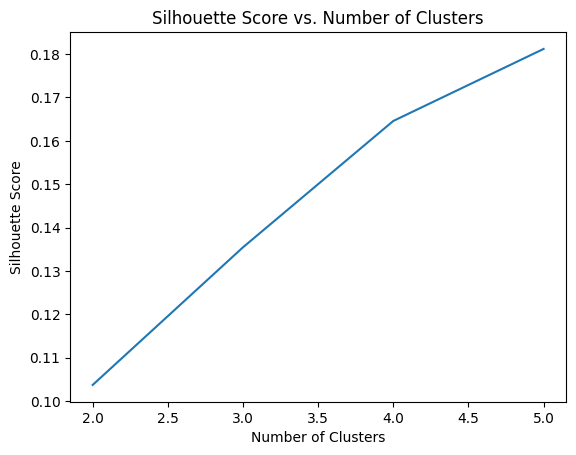

In [15]:
import matplotlib.pyplot as plt

plt.plot(range(2,6), sil_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.show()

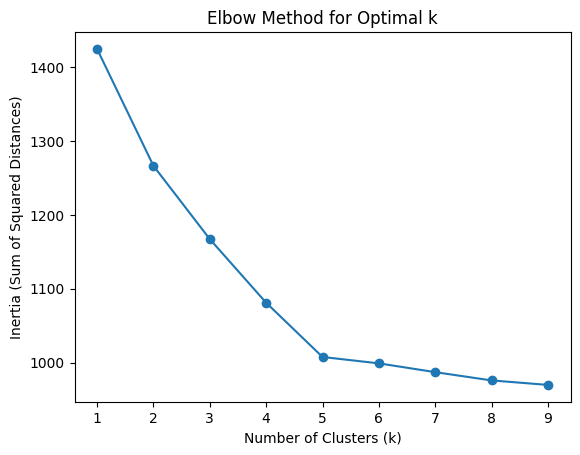

In [16]:
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_matrix)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [17]:
#from the tickets remove stop words, lemmatize it and use tdidf vectorizer

import gspread
from google.oauth2.service_account import Credentials
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

#Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    words = text.lower().split()
    words = [word for word in words if word not in stop_words and word.isalnum()] # Remove stop words and non-alphanumeric
    words = [lemmatizer.lemmatize(word) for word in words] #Lemmatization
    return " ".join(words)

data1['processed_answer'] = data1['answer'].apply(preprocess_text)


#TF-IDF VECTORIZATION FOR COMPLETE DATASET
tfidf_vectorizer = TfidfVectorizer(max_features=1000) #Stop words already removed during preprocessing
tfidf_matrix = tfidf_vectorizer.fit_transform(data1['processed_answer'])

tfidf_data1 = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(tfidf_data1.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


    10        13       365  3755  9310  abläufe  abordar  access  account  \
0  0.0  0.000000  0.000000   0.0   0.0      0.0      0.0     0.0      0.0   
1  0.0  0.159667  0.000000   0.0   0.0      0.0      0.0     0.0      0.0   
2  0.0  0.000000  0.000000   0.0   0.0      0.0      0.0     0.0      0.0   
3  0.0  0.000000  0.000000   0.0   0.0      0.0      0.0     0.0      0.0   
4  0.0  0.000000  0.106117   0.0   0.0      0.0      0.0     0.0      0.0   

   acelerar  ...    zögern   às  änderungen  équipe  étapes  être  última  \
0       0.0  ...  0.000000  0.0         0.0     0.0     0.0   0.0     0.0   
1       0.0  ...  0.000000  0.0         0.0     0.0     0.0   0.0     0.0   
2       0.0  ...  0.158668  0.0         0.0     0.0     0.0   0.0     0.0   
3       0.0  ...  0.063497  0.0         0.0     0.0     0.0   0.0     0.0   
4       0.0  ...  0.000000  0.0         0.0     0.0     0.0   0.0     0.0   

       über  überprüfen  überprüfung  
0  0.000000    0.000000          0.

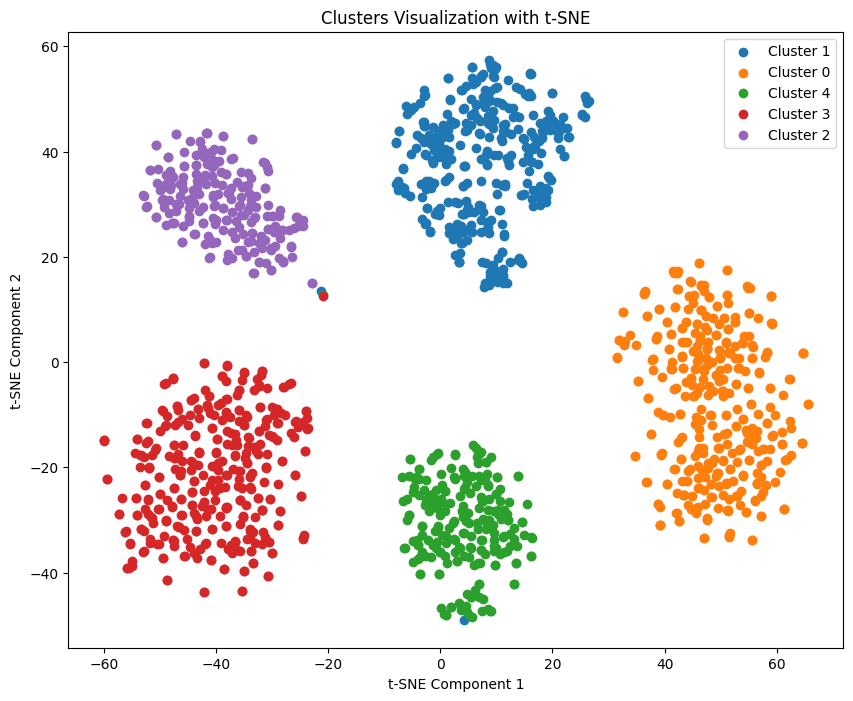

In [18]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Assuming 'data1' and 'tfidf_matrix' are defined from the previous code

# Reduce dimensions using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(tfidf_matrix.toarray())

# Add the reduced dimensions to the DataFrame
data1['tsne_x'] = X_tsne[:, 0]
data1['tsne_y'] = X_tsne[:, 1]

# Plot the clusters in 2D
plt.figure(figsize=(10, 8))
for cluster in data1['cluster'].unique():
    plt.scatter(data1[data1['cluster'] == cluster]['tsne_x'],
                data1[data1['cluster'] == cluster]['tsne_y'],
                label=f'Cluster {cluster}')

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Clusters Visualization with t-SNE')
plt.legend()
plt.show()

In [19]:
# Cluster profiling with top terms
from collections import Counter

for cluster in data1['cluster'].unique():
    cluster_docs = data1[data1['cluster'] == cluster]['answer']
    word_counts = Counter(" ".join(cluster_docs).split())
    print(f"Cluster {cluster}: Top 5 words - {word_counts.most_common(5)}")

# Evaluate clustering with silhouette score
from sklearn.metrics import silhouette_score

score = silhouette_score(tfidf_matrix, data1['cluster'])
print(f"Silhouette Score: {score}")


Cluster 1: Top 5 words - [('the', 1710), ('to', 1353), ('and', 1131), ('your', 1102), ('you', 879)]
Cluster 0: Top 5 words - [('Sie', 2342), ('die', 1648), ('zu', 1316), ('und', 1301), ('uns', 742)]
Cluster 4: Top 5 words - [('de', 1612), ('para', 832), ('e', 793), ('o', 738), ('em', 690)]
Cluster 3: Top 5 words - [('de', 3769), ('y', 1287), ('la', 1278), ('en', 1052), ('para', 1008)]
Cluster 2: Top 5 words - [('de', 1837), ('et', 785), ('à', 781), ('votre', 678), ('nous', 648)]
Silhouette Score: 0.19207161928287764


In [20]:
# Creating tf-idf{Term frequency - Inverse Document Frequency} for 'answer' column

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def create_tfidf_for_answers(data1):

    #Initializing
    vectorizer = TfidfVectorizer()

    # Fit and transform
    tfidf_matrix = vectorizer.fit_transform(data1['answer'].astype(str))

    # Feature names
    feature_names = vectorizer.get_feature_names_out()

    # Dataframe
    tfidf_data1 = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

    return tfidf_data1

tfidf_answers = create_tfidf_for_answers(data1)
tfidf_answers.head()

,10,11,12345678,13,15,18,1811528,19c,20,2021,...,übersehene,übersehenes,übersicht,übertragung,überwachen,überwacht,überwachung,überwachungsfähigkeiten,üblichen,œuvre
0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.072893,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.066198,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
tfidf_answers.shape

(1566, 11329)

In [22]:
import numpy as np
tfidf_sum = tfidf_answers.sum(axis=0)
term_frequencies = np.array(tfidf_sum).flatten()
display(tfidf_sum)
display(term_frequencies)

,0
10,2.682445
11,2.870042
12345678,0.585553
13,7.542847
15,1.706996
...,...
überwacht,0.188619
überwachung,0.342697
überwachungsfähigkeiten,0.129021
üblichen,0.157605


array([2.68244503, 2.87004189, 0.58555285, ..., 0.12902074, 0.15760502,
       1.13024404])

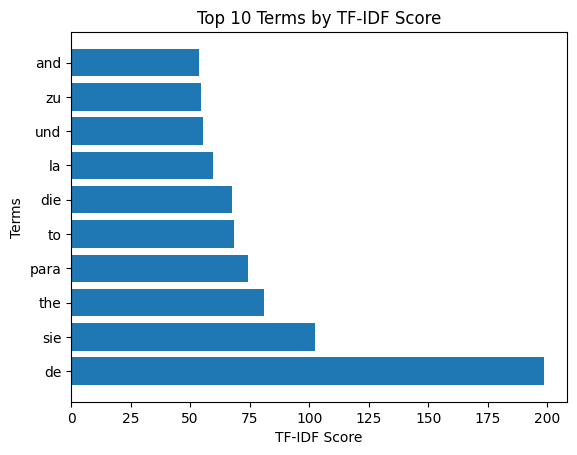

In [23]:
import matplotlib.pyplot as plt
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(data1['answer'].astype(str))

feature_names = vectorizer.get_feature_names_out()
term_freq = np.array(tfidf_answers.sum(axis=0)).flatten()
sorted_idx = np.argsort(term_freq)[::-1][:10]
plt.barh([feature_names[i] for i in sorted_idx], term_freq[sorted_idx])
plt.xlabel("TF-IDF Score")
plt.ylabel("Terms")
plt.title("Top 10 Terms by TF-IDF Score")
plt.show()


In [25]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(tfidf_answers)
print(clusters)

import pandas as pd
tfidf_answers['cluster'] = clusters
tfidf_answers[['cluster']].head()

[2 2 0 ... 1 4 4]


,cluster
0,2
1,2
2,0
3,0
4,1


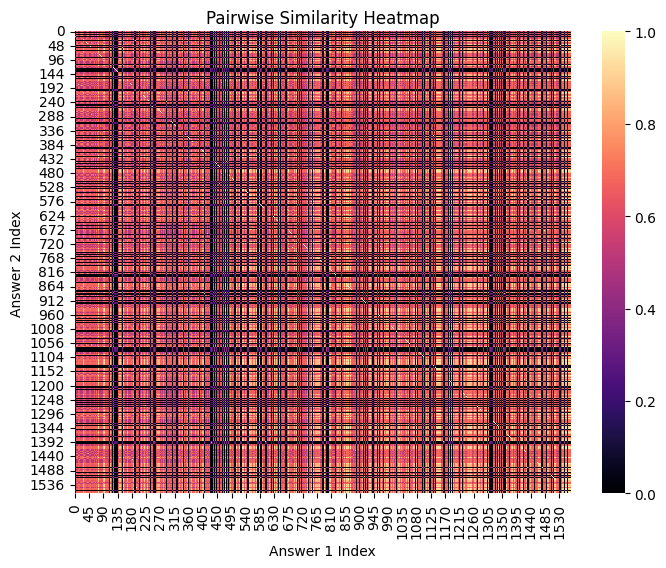

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

similarity_matrix = cosine_similarity(tfidf_answers)

similarity_data1 = pd.DataFrame(similarity_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_data1, cmap="magma")
plt.xlabel("Answer 1 Index")
plt.ylabel("Answer 2 Index")
plt.title("Pairwise Similarity Heatmap")
plt.show()

<ipython-input-59-a60eb38af745>:4: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



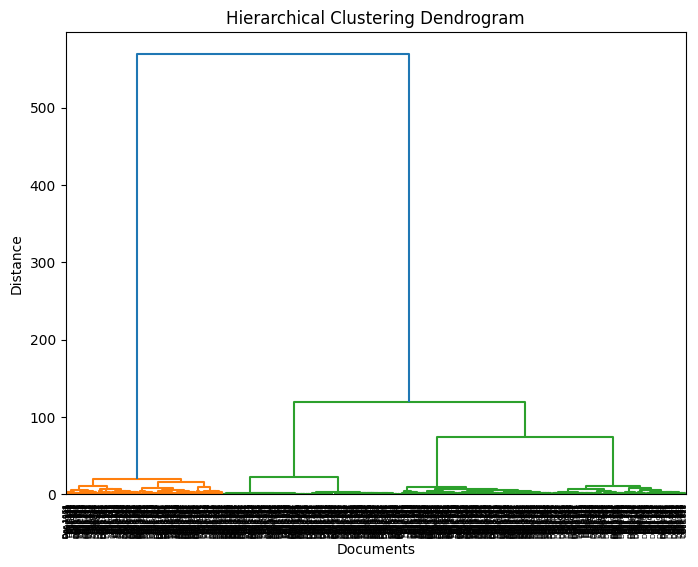

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_distances

linkage_matrix = linkage(cosine_distances(tfidf_answers), method='ward')

plt.figure(figsize=(8, 6))
dendrogram(linkage_matrix, labels=[f"Doc {i+1}" for i in range(tfidf_answers.shape[0])])
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Documents")
plt.ylabel("Distance")
plt.show()

In [ ]:
import numpy as np

n = similarity_matrix.shape[0]
np.fill_diagonal(similarity_matrix, 0)
top_k = 5
top_pairs = np.dstack(np.unravel_index(np.argsort(similarity_matrix.ravel())[::-1], (n, n)))[0][:top_k]

print("Top Similar Document Pairs:")
for i, j in top_pairs:
    print(f"Doc {i+1} and Doc {j+1} with similarity {similarity_matrix[i, j]:.2f}")

Top Similar Document Pairs:
Doc 855 and Doc 967 with similarity 1.00
Doc 967 and Doc 855 with similarity 1.00
Doc 1387 and Doc 1152 with similarity 1.00
Doc 1152 and Doc 1387 with similarity 1.00
Doc 1113 and Doc 1116 with similarity 1.00


In [ ]:
import plotly.express as px

fig = px.imshow(similarity_matrix,
                labels=dict(x="Document Index", y="Document Index", color="Similarity"),
                color_continuous_scale="Viridis")
fig.update_layout(title="Pairwise Similarity Heatmap", width=800, height=600)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [27]:
!pip install nltk
import nltk
nltk.download('punkt_tab')

# Assume df_en is loaded from a file or created here. Example:
import pandas as pd
# Replace 'your_data.csv' with the actual file path if loading from a file.
# df_en = pd.read_csv('your_data.csv')

# If creating a new DataFrame:
# df_en = pd.DataFrame(your_data, columns=['column1', 'column2', ...])

# Assuming there is an issue with df_en not being defined,
# Let's assume it's coming from 'data1' and contains 'subject' and you'll extract tags later.
df_en = data1[['subject']].copy()  # Creating a sample df_en for demonstration

# Now, the rest of the code should work:
tag_columns = [col for col in df_en.columns if col.startswith('tag_')]
df_en['combined_tags'] = df_en[tag_columns].apply(lambda row: ' '.join(row.dropna().astype(str)), axis=1)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Get the list of stop words
stop_words = set(stopwords.words('english')) # Get the list of stopwords using stopwords.words('english')

# Tokenize, sort, and create a string of unique tokens
def process_tags(text):
    tokens = nltk.word_tokenize(text.lower())
    lemmatizer = WordNetLemmatizer() # Instantiate WordNetLemmatizer within the function
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalnum() and token not in stop_words]
    unique_tokens = sorted(list(set(tokens)))
    return ' '.join(unique_tokens)

df_en['unique_tags'] = df_en['combined_tags'].apply(process_tags)

# Now, you can extract tags or use df_en in your analysis
print(df_en['unique_tags'].value_counts())

unique_tags
    1566
Name: count, dtype: int64


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [36]:
pip install langdetect

In [37]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from langdetect import detect
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Encoding categorical columns (language, queue, issue_type)
def encode_categorical_columns(df):
    le_lang = LabelEncoder()
    le_queue = LabelEncoder()
    le_type = LabelEncoder()

    df['lang_encoded'] = le_lang.fit_transform(df['language'])
    df['queue_encoded'] = le_queue.fit_transform(df['queue'])
    df['type_encoded'] = le_type.fit_transform(df['type'])

    return df, le_lang, le_queue, le_type

    encoded_data1, le_lang, le_queue, le_type = encode_categorical_columns(data1)

    display(encoded_data1.head())

    print(encoded_data1['lang_encoded'])

In [38]:
# Perform clustering using encoded language, queue, and issue type
def perform_clustering(df, n_clusters):
    features = data1[['lang_encoded', 'queue_encoded', 'type_encoded']]
    kmeans = KMeans(n_clusters=n_clusters)
    data1['cluster'] = kmeans.fit_predict(features)
    return df, kmeans

# Generate a response template based on the cluster
def generate_response(issue_description, df, kmeans, le_lang, le_queue, le_type):
    # Detect language of the issue description
    try:
        lang_pred = detect(issue_description)  # Detect the language from the input text
    except:
        lang_pred = 'en'  # Default language if detection fails

    # Assume default queue and issue type if these aren't inferred from the prompt
    queue_pred = 'Technical Support'  # Example, you can adjust based on your needs
    type_pred = 'Incident'  # Example, you can adjust based on your needs

    # Encode the predicted language, queue, and type
    lang_pred_encoded = le_lang.transform([lang_pred])[0]
    queue_pred_encoded = le_queue.transform([queue_pred])[0]
    type_pred_encoded = le_type.transform([type_pred])[0]

    # Predict the cluster based on these encoded values
    cluster_pred = kmeans.predict([[lang_pred_encoded, queue_pred_encoded, type_pred_encoded]])[0]

    # Filter the data by predicted cluster
    cluster_data = df[df['cluster'] == cluster_pred]

    if cluster_data.empty:
        return "Sorry, we couldn't identify your issue due to insufficient data."

    # Filter the answers in the cluster by the predicted language
    cluster_data_lang_filtered = cluster_data[cluster_data['language'] == lang_pred]

    if cluster_data_lang_filtered.empty:
        # If no answers in the predicted language, return a default response
        return "Sorry, we couldn't provide a response in your language."

    # Use TF-IDF to calculate the similarity between the issue description and the answers in the cluster
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(cluster_data_lang_filtered['answer'].tolist() + [issue_description])

    # Compute cosine similarity between the issue description and all answers
    similarity_scores = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1]).flatten()

    # Get the index of the most similar answer
    most_similar_idx = similarity_scores.argmax()

    # Get the most similar answer based on cosine similarity
    response = cluster_data_lang_filtered['answer'].iloc[most_similar_idx]

    # Use a template to structure the response
    response_template = f"Thank you for contacting us. Based on your issue, here's the most relevant response: \n\n{response}"

    return response_template

# Main script that processes the data
def main():
    # Encode the categorical columns
    #Fixing the indentation error here within the main function
    dt1, le_lang, le_queue, le_type = encode_categorical_columns(data1)

    # Perform clustering based on the encoded features
    n_clusters = 3  # Adjust based on the dataset
    df1, kmeans = perform_clustering(dt1, n_clusters) #passing the encoded data1 dataframe as dt1


    # Test with a sample issue (only issue_description as input)
    test_issue = "Our network is down, and we need urgent assistance!"

    # Generate a response for the sample issue
    response = generate_response(test_issue, df1, kmeans, le_lang, le_queue, le_type)

    # Output the response
    print("Automated Response:", response)

# Run the main function
if __name__ == "__main__":
    main()

Automated Response: Thank you for contacting us. Based on your issue, here's the most relevant response: 

Subject: Re: Urgent Support Inquiry


Dear <name>,


Thank you for reaching out regarding your urgent IT Consulting Service needs. We fully understand the need to promptly address the server setup and network optimization issues to ensure uninterrupted business activities.


I have expedited your request for priority assistance and assigned a specialist proficient in server configurations and enhancement strategies to help you. Our support team will connect with you soon to schedule a consultation call and gather further details to expedite the resolution.


Please expect a timely reply, and feel free to get in touch with us at <tel_num> if you have any additional questions or concerns in the meantime.


Warm regards,


<Service Desk Agent Name>
Customer Support Team


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from langdetect import detect
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch

# Load the fine-tuned model and tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Function to predict queue and issue type using the fine-tuned model
def predict_queue_and_type(issue_description, model, tokenizer):
    inputs = tokenizer(issue_description, return_tensors="pt", padding=True, truncation=True, max_length=512)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_labels = torch.argmax(logits, dim=-1)

    # Assuming 0 is for "Technical Support", 1 is for "Customer Service", etc.
    queue_prediction = predicted_labels[0].item()

    # Add issue type prediction if you fine-tuned for both queue and type in the model
    return queue_prediction

# Encode the categorical columns
def encode_categorical_columns(df):
    le_lang = LabelEncoder()
    le_queue = LabelEncoder()
    le_type = LabelEncoder()

    data1['lang_encoded'] = le_lang.fit_transform(df['language'])
    data1['queue_encoded'] = le_queue.fit_transform(df['queue'])
    data1['type_encoded'] = le_type.fit_transform(df['type'])

    return df, le_lang, le_queue, le_type

# Perform clustering using encoded language, queue, and issue type
def perform_clustering(df, n_clusters):
    features = df[['lang_encoded', 'queue_encoded', 'type_encoded']]
    kmeans = KMeans(n_clusters=n_clusters)
    data1['cluster'] = kmeans.fit_predict(features)
    return df, kmeans

# Generate response based on predicted queue and issue type
def generate_response(issue_description, df, kmeans, le_lang, le_queue, le_type, model, tokenizer):
    # Predict queue and type dynamically
    predicted_queue = predict_queue_and_type(issue_description, model, tokenizer)

    # Map the predicted queue to the corresponding label (e.g., 0 -> "Technical Support")
    try:
        predicted_queue_label = le_queue.inverse_transform([predicted_queue])[0]
    except ValueError:
        predicted_queue_label = "Unknown Queue"  # Default value if label not found

    predicted_type = "Incident"  # Adjust accordingly based on your fine-tuning

    # Encode predicted queue and type
    try:
        predicted_queue_encoded = le_queue.transform([predicted_queue_label])[0]
    except ValueError:
        predicted_queue_encoded = le_queue.transform(["Unknown Queue"])[0]

    predicted_type_encoded = le_type.transform([predicted_type])[0]

    # Encode the predicted language
    lang_pred = 'en'  # Assume 'en' for simplicity or detect dynamically
    lang_pred_encoded = le_lang.transform([lang_pred])[0]

    # Prepare a pandas DataFrame with feature names for prediction
    prediction_data = pd.DataFrame(
        [[lang_pred_encoded, predicted_queue_encoded, predicted_type_encoded]],
        columns=['lang_encoded', 'queue_encoded', 'type_encoded']  # Ensure feature names match
    )

    # Predict the cluster based on the predicted features (language, queue, type)
    cluster_pred = kmeans.predict(prediction_data)[0]

    # Filter the data by predicted cluster
    cluster_data = data1[data1['cluster'] == cluster_pred]

    if cluster_data.empty:
        return "Sorry, we couldn't identify your issue due to insufficient data."

    # Filter the answers in the cluster by the predicted language
    cluster_data_lang_filtered = cluster_data[cluster_data['language'] == 'en']  # Assume English for simplicity

    if cluster_data_lang_filtered.empty:
        return "Sorry, we couldn't provide a response in your language."

    # Use TF-IDF to calculate the similarity between the issue description and the answers in the cluster
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(cluster_data_lang_filtered['answer'].tolist() + [issue_description])

    # Compute cosine similarity
    similarity_scores = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1]).flatten()

    # Get the most similar answer
    most_similar_idx = similarity_scores.argmax()
    response = cluster_data_lang_filtered['answer'].iloc[most_similar_idx]

    return f"Thank you for contacting us. Based on your issue, here's the most relevant response: \n\n{response}"

# Main script to process the data
def main():
    df1, le_lang, le_queue, le_type = encode_categorical_columns(data1)
    df1, kmeans = perform_clustering(df1, n_clusters=3)

    test_issue = "Our network is down, and we need urgent assistance!"

    response = generate_response(test_issue, df1, kmeans, le_lang, le_queue, le_type, model, tokenizer)

    print("Automated Response:", response)

# Run the main function
if __name__ == "__main__":
    main()



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Automated Response: Thank you for contacting us. Based on your issue, here's the most relevant response: 

Subject: Re: Urgent Server Admin Interface Issue


Dear <name>,


Thank you for reporting this urgent issue with your server admin interface. I understand the critical nature of this problem and its impact on your operations. Our technical team is already reviewing your case as a priority and will be reaching out to coordinate directly with your IT staff.


We are committed to providing the fastest resolution possible to minimize any disruption to your business. Please expect further communication shortly to address and rectify the situation.


If there are any further changes or additional details you wish to convey, do let us know.


Thank you for your patience and cooperation.


Best regards,
<Customer Support Team>


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from langdetect import detect
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Encoding categorical columns (language, queue, issue_type)
def encode_categorical_columns(df):
    le_lang = LabelEncoder()
    le_queue = LabelEncoder()
    le_type = LabelEncoder()

    df['lang_encoded'] = le_lang.fit_transform(df['language'])
    df['queue_encoded'] = le_queue.fit_transform(df['queue'])
    df['type_encoded'] = le_type.fit_transform(df['type'])

    return df, le_lang, le_queue, le_type

# Perform clustering using encoded language, queue, and issue type
def perform_clustering(df, n_clusters):
    features = df[['lang_encoded', 'queue_encoded', 'type_encoded']]
    kmeans = KMeans(n_clusters=n_clusters)
    df['cluster'] = kmeans.fit_predict(features)
    return df, kmeans

# Generate a response template based on the cluster and escalation logic
def generate_response(issue_description, df, kmeans, le_lang, le_queue, le_type):
    try:
        lang_pred = detect(issue_description)
    except:
        lang_pred = 'en'

    queue_pred = 'Technical Support'
    type_pred = 'Incident'

    lang_pred_encoded = le_lang.transform([lang_pred])[0]
    queue_pred_encoded = le_queue.transform([queue_pred])[0]
    type_pred_encoded = le_type.transform([type_pred])[0]

    cluster_pred = kmeans.predict([[lang_pred_encoded, queue_pred_encoded, type_pred_encoded]])[0]

    # Escalation triggers
    escalation_keywords = ["urgent", "critical", "network down", "system outage"]
    escalation_clusters = [2]
    similarity_threshold = 0.7

    # Escalation logic:
    if any(keyword in issue_description.lower() for keyword in escalation_keywords) or \
            cluster_pred in escalation_clusters:
        escalation_record = {
            "issue_description": issue_description,
            "predicted_language": lang_pred,
            "predicted_queue": queue_pred,
            "predicted_type": type_pred,
            "cluster": cluster_pred
        }
        print("Issue Escalated:", escalation_record)
        return "Thank you for contacting us. This issue has been escalated and will be addressed by a specialist shortly."

    # Filter the data by predicted cluster
    cluster_data = df[df['cluster'] == cluster_pred]

    # If no data for the cluster, return a default response and escalate
    if cluster_data.empty:
        print("Issue Escalated: No data for predicted cluster")
        return "Thank you for contacting us. We are reviewing your request and will get back to you soon."

    cluster_data_lang_filtered = cluster_data[cluster_data['language'] == lang_pred]

    # If no data for the language within the cluster, return a default response and escalate
    if cluster_data_lang_filtered.empty:
        print("Issue Escalated: No data for predicted language within cluster")
        return "Thank you for contacting us. We are reviewing your request and will get back to you soon."

    # Use TF-IDF and cosine similarity to find the most similar answer
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(cluster_data_lang_filtered['answer'].tolist() + [issue_description])
    similarity_scores = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1]).flatten()

    # Similarity-based escalation:
    if max(similarity_scores) < similarity_threshold:
        escalation_record = {
            "issue_description": issue_description,
            "predicted_language": lang_pred,
            "predicted_queue": queue_pred,
            "predicted_type": type_pred,
            "cluster": cluster_pred,
            "max_similarity": max(similarity_scores)
        }
        print("Issue Escalated (Low Similarity):", escalation_record)
        return "Thank you for contacting us. We are reviewing your request and will get back to you soon."

    # If no escalation is triggered, return the most similar answer
    most_similar_idx = similarity_scores.argmax()
    response = cluster_data_lang_filtered['answer'].iloc[most_similar_idx]
    return f"Thank you for contacting us. Based on your issue, here's the most relevant response: \n\n{response}"


# Main script that processes the data
def main():
    # Encode the categorical columns
    encoded_data1, le_lang, le_queue, le_type = encode_categorical_columns(data1)

    # Perform clustering based on the encoded features
    n_clusters = 3
    clustered_data1, kmeans = perform_clustering(encoded_data1, n_clusters)

    # Test with a sample issue
    test_issue = "Our network is down, and we need urgent assistance!"  # This should trigger escalation due to keywords
    # test_issue = "I need help resetting my password."  # This might not trigger escalation

    # Generate a response for the sample issue
    response = generate_response(test_issue, clustered_data1, kmeans, le_lang, le_queue, le_type)

    # Output the response
    print("Automated Response:", response)

# Run the main function
if __name__ == "__main__":
    main()

Issue Escalated: {'issue_description': 'Our network is down, and we need urgent assistance!', 'predicted_language': 'en', 'predicted_queue': 'Technical Support', 'predicted_type': 'Incident', 'cluster': 0}
Automated Response: Thank you for contacting us. This issue has been escalated and will be addressed by a specialist shortly.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [30]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-mpnet-base-v2')

tickets = data1['answer'].tolist()

# Generate embeddings
embeddings = model.encode(tickets)

print(embeddings.shape)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(1566, 768)


In [31]:
# Assuming 'embeddings' is your NumPy array of ticket embeddings and 'data1' is your DataFrame.
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.cluster import KMeans # Import KMeans

pca = PCA(n_components=3)
ticket_embeddings_pca = pca.fit_transform(embeddings)
pca_df = pd.DataFrame(data=ticket_embeddings_pca, columns=['PC1', 'PC2', 'PC3'])

# Reset index of data1 to match the embeddings
data1 = data1.reset_index(drop=True)

# Ensure data1 and pca_df have the same number of rows
pca_df = pca_df.iloc[:len(data1)]  # Truncate pca_df to match data1 length

kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust n_clusters as needed
data1['cluster'] = kmeans.fit_predict(embeddings) # Fit on your embeddings

# Create 'combined_tags' column based on 'cluster'
if 'combined_tags' not in data1.columns:
    data1['combined_tags'] = data1['cluster'].astype(str)

# Now create the plot
fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3', color=data1['combined_tags'], title='3D Scatter Plot of Ticket Embeddings')
fig.show()

In [32]:
# prompt: use ner model on subject, to get out nouns_and_entities

!pip install spacy
!python -m spacy download en_core_web_sm

import spacy

# Load the English language model
nlp = spacy.load("en_core_web_sm")

# Example usage with a subject from your DataFrame
subjects = df_en["subject"].tolist()

# Function to extract both nouns and entities
def extract_nouns_and_entities(text):
    doc = nlp(text)
    nouns_and_entities = [token.text for token in doc if token.pos_ == "NOUN"]
    entities = [ent.text for ent in doc.ents]
    return nouns_and_entities + entities

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 23.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [33]:
!pip install sentence-transformers
!pip install spacy
!python -m spacy download en_core_web_sm

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import numpy as np

# Ensure embeddings and df_en have the same number of rows
embeddings = embeddings[:len(df_en)]

kmeans = KMeans(n_clusters=5, random_state=42)  # 4 clusters
kmeans.fit(embeddings)
df_en['cluster'] = kmeans.labels_

# Analyze clusters
issue_percentages = {}
for cluster_id in range(5): # Change to 5 clusters for consistency
    cluster_data = df_en[df_en['cluster'] == cluster_id]
    subject_counts = cluster_data['subject'].value_counts(normalize=True) * 100
    issue_percentages[f'Cluster {cluster_id}'] = subject_counts

    print(f"\nCluster {cluster_id} recurring issues:")
    for issue, percentage in subject_counts.items():
        print(f"- {issue}: {percentage:.2f}%")

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Cluster 0 recurring issues:
- Dringend: Unterstützung für die Datenwiederherstellung von MySQL 8.0.30 benötigt: 0.38%
- Intermittierende Konnektivitätsprobleme melden: 0.38%
- Dringende AWS-Bereitstellungsprobleme: 0.38%
- Unterstützung bei Adobe Photoshop: 0.38%
- Anfrage zur Änderung der Benutzberechtigungen: 0.38%
- Problem mit dem Ticket-System: 0.38%
- Anfrage für Produktaustausch - Defekte Batterie: 0.38%
- Leistungsprobleme mit MySQL 8.0.30 Datenbank: 0.38%
- Anfrage zur Unterstützung bei einem Installation

In [34]:
# prompt: Create a frequency-based ranking system to highlight the most common issue using queue column and print them too and create rankings based on frequency

from collections import Counter

# Assuming 'data1' is your DataFrame and 'queue' is the column with queue information
queue_counts = Counter(data1['queue'])

# Print the frequency of each queue
for queue, count in queue_counts.items():
    print(f"Queue: {queue}, Frequency: {count}")

# Create a ranking based on frequency
ranked_queues = queue_counts.most_common()

print("\nRanked Queues (Most Frequent First):")
for rank, (queue, count) in enumerate(ranked_queues, 1):
    print(f"{rank}. Queue: {queue}, Frequency: {count}")

Queue: Technical Support, Frequency: 589
Queue: Product Support, Frequency: 288
Queue: Sales and Pre-Sales, Frequency: 49
Queue: Returns and Exchanges, Frequency: 44
Queue: IT Support, Frequency: 179
Queue: Billing and Payments, Frequency: 117
Queue: Customer Service, Frequency: 234
Queue: Service Outages and Maintenance, Frequency: 44
Queue: Human Resources, Frequency: 9
Queue: General Inquiry, Frequency: 13

Ranked Queues (Most Frequent First):
1. Queue: Technical Support, Frequency: 589
2. Queue: Product Support, Frequency: 288
3. Queue: Customer Service, Frequency: 234
4. Queue: IT Support, Frequency: 179
5. Queue: Billing and Payments, Frequency: 117
6. Queue: Sales and Pre-Sales, Frequency: 49
7. Queue: Returns and Exchanges, Frequency: 44
8. Queue: Service Outages and Maintenance, Frequency: 44
9. Queue: General Inquiry, Frequency: 13
10. Queue: Human Resources, Frequency: 9


In [35]:

def name_clusters(cluster_data):
    """
    Names clusters based on the most frequent product names found in subjects.
    """
    cluster_names = {}
    for cluster_id in cluster_data:
        subjects = cluster_data[cluster_id]
        product_counts = {}
        for subject in subjects:
            # Lowercase the subject for case-insensitive matching
            subject = subject.lower()

            if "cisco" in subject and "router" in subject:
                product_counts["Cisco Router"] = product_counts.get("Cisco Router", 0) + 1
            elif "aws" in subject:
                product_counts["AWS"] = product_counts.get("AWS", 0) + 1
            elif "dell xps" in subject:
                product_counts["Dell XPS"] = product_counts.get("Dell XPS", 0) + 1
            elif "printer" in subject:
                product_counts["Printer"] = product_counts.get("Printer", 0) + 1
            elif "hp printer" in subject:
                product_counts["HP Printer"] = product_counts.get("HP Printer", 0) + 1
            elif "zoom" in subject:
                product_counts["Zoom"] = product_counts.get("Zoom", 0) + 1
            elif "jira" in subject:
                product_counts["Jira"] = product_counts.get("Jira", 0) + 1
            elif "mysql" in subject:
                product_counts["MySQL"] = product_counts.get("MySQL", 0) + 1
            elif "postgresql" in subject:
                product_counts["PostgreSQL"] = product_counts.get("PostgreSQL", 0) + 1
            elif "visual studio" in subject or "vs code" in subject:
                product_counts["VS Code"] = product_counts.get("VS Code", 0) + 1
            elif "office 365" in subject:
                product_counts["Office 365"] = product_counts.get("Office 365", 0) + 1
            elif "slack" in subject:
                product_counts["Slack"] = product_counts.get("Slack", 0) + 1
            elif "adobe photoshop" in subject:
                product_counts["Adobe Photoshop"] = product_counts.get("Adobe Photoshop", 0) + 1



        if product_counts:
            most_frequent_product = max(product_counts, key=product_counts.get)
            cluster_names[cluster_id] = most_frequent_product
        else:
            cluster_names[cluster_id] = f"Cluster {cluster_id} (Unknown)"
    return cluster_names


cluster_data = {
    0: ["Cisco Router Issue", "AWS Downtime", "Printer Error", "Dell XPS screen problem"],
    1: ["AWS Connection Problem", "AWS Server Error", "AWS Management Console Issue", "AWS API Error", "AWS Instance Unresponsive", "AWS Security Group Configuration"],
    2: ["Cisco Router Configuration", "Cisco Router Reboot", "Cisco Router Connectivity"],
    3: ["Printer Jam", "Printer Out of Ink", "HP Printer Offline"],
    4: ["Router Configuration Error", "Printer Connectivity Issue", "Server Downtime", "Laptop Battery Issue"]
}


cluster_names = name_clusters(cluster_data)
print(cluster_names)

{0: 'Cisco Router', 1: 'AWS', 2: 'Cisco Router', 3: 'Printer', 4: 'Printer'}


In [38]:
def generate_top_issue_responses(df, cluster_names):
    """Generates response templates for the top 2 issues in each cluster."""

    top_issue_responses = {}
    for cluster_id, cluster_name in cluster_names.items():
        cluster_subjects = df[df["cluster"] == cluster_id]["subject"]

         # Refined matching with keyword list
        keywords = cluster_name.lower().split()  # Using the cluster name as base keywords
        matching_subjects = cluster_subjects[
            cluster_subjects.str.lower().apply(lambda x: any(keyword in x for keyword in keywords))
        ]

        if matching_subjects.empty:
            print(f"No subjects found for cluster {cluster_id} ({cluster_name})")
            continue

        # Get top two subjects, handling cases where less than two subjects exist
        top_2_subjects = matching_subjects.value_counts().nlargest(2).index.tolist()

        top_issue_responses[cluster_name] = []

        for subject in top_2_subjects:
           # Find the corresponding answer from 'df_en'
            answers = data1[(data1["cluster"] == cluster_id) & (data1["subject"] == subject)]["answer"]
            if not answers.empty:
              # Use the first answer. Consider more sophisticated selection if needed.
                answer = answers.iloc[0]
                response_template = f"Subject: Re: {subject}\n\n" \
                                     f"Dear Customer,\n\n" \
                                     f"Thank you for contacting us regarding {subject}.\n\n" \
                                     f"{answer}\n\n" \
                                     "Best regards,\n" \
                                     f"Support Team"
                top_issue_responses[cluster_name].append({"subject":subject, "response":response_template})
            else:
                print(f"No corresponding answer found for subject: {subject}")

    return top_issue_responses

top_responses = generate_top_issue_responses(df_en, cluster_names)

for cluster, issues in top_responses.items():
    print(f"\nCluster: {cluster}")
    for issue_data in issues:
        print(issue_data["subject"])
        print(issue_data["response"])

No subjects found for cluster 3 (Printer)

Cluster: Cisco Router
Problemas con el Router Cisco ISR4331
Subject: Re: Problemas con el Router Cisco ISR4331

Dear Customer,

Thank you for contacting us regarding Problemas con el Router Cisco ISR4331.

Estimado/a <name>,


Gracias por contactarnos sobre los problemas con su router Cisco ISR4331. Las desconexiones frecuentes y el rendimiento lento a menudo pueden resolverse mediante actualizaciones del firmware o ajustes de configuración. Asegúrese de que el firmware del router esté actualizado. Puede descargar las últimas actualizaciones desde el sitio web oficial de Cisco. Además, verifique la configuración del router en busca de anomalías.


Si el problema persiste, le recomiendo realizar un reinicio de fábrica y reconfigurar los ajustes. También podría considerar contactar a un técnico certificado de Cisco para un análisis más profundo.


No dude en ponerse en contacto con nosotros para obtener más ayuda. Estamos aquí para ayudar a rest

In [42]:
def automated_response(incoming_issue):
    incoming_subject = incoming_issue["subject"].lower()
    incoming_body = incoming_issue["body"].lower()

    best_match = None
    best_response = None
    best_similarity = -1

    for cluster, issues in top_responses.items():
        for issue_data in issues:
            subject = issue_data["subject"].lower()
           # Refined Cluster Matching (check if keywords in the subject or body)
            if any(keyword in incoming_subject for keyword in cluster.lower().split()) or \
               any(keyword in incoming_body for keyword in cluster.lower().split()):
                similarity = 1  # Set high similarity for cluster match
                if similarity > best_similarity:
                    best_similarity = similarity
                    best_match = issue_data["subject"]
                    best_response = issue_data["response"]

            else:  # Subject matching
                similarity = 0
                if subject in incoming_subject:
                    similarity = 0.8
                elif subject in incoming_body:
                    similarity = 0.8

                if similarity > best_similarity:
                    best_similarity = similarity
                    best_match = issue_data["subject"]
                    best_response = issue_data["response"]

    if best_response:
        return best_response
    else:
        return "I'm sorry, I couldn't find an appropriate response for your issue. Please provide more details."

incoming_issue = {"subject":"Critical impact on enterprise network connectivity", "body":" Dear Customer Support Team, We are experiencing a complete outage affecting our enterprise network involving Cisco Router ISR4331. This disruption is critically impacting our secure WAN connectivity across all domains, urgently requiring your immediate intervention. Due to this issue, our company has halted various essential operations, significantly affecting our services and commitments to clients. As our technical team has not been able to resolve the problem internally, we need your expert support to diagnose and rectify this issue swiftly. Please consider this a high priority and provide us with the necessary technical assistance to restore our network’s functionality. Thank you for your prompt attention. Best regards, , IT Manager at  "}
response = automated_response(incoming_issue)
print(response)

Subject: Re: Problemas con el Router Cisco ISR4331

Dear Customer,

Thank you for contacting us regarding Problemas con el Router Cisco ISR4331.

Estimado/a <name>,


Gracias por contactarnos sobre los problemas con su router Cisco ISR4331. Las desconexiones frecuentes y el rendimiento lento a menudo pueden resolverse mediante actualizaciones del firmware o ajustes de configuración. Asegúrese de que el firmware del router esté actualizado. Puede descargar las últimas actualizaciones desde el sitio web oficial de Cisco. Además, verifique la configuración del router en busca de anomalías.


Si el problema persiste, le recomiendo realizar un reinicio de fábrica y reconfigurar los ajustes. También podría considerar contactar a un técnico certificado de Cisco para un análisis más profundo.


No dude en ponerse en contacto con nosotros para obtener más ayuda. Estamos aquí para ayudar a restaurar sus operaciones rápidamente.


Atentamente,
[Su equipo de soporte]

Best regards,
Support Team


In [43]:
# Assuming df_en and embeddings (from SentenceTransformer) are defined
from sklearn.cluster import KMeans
import pandas as pd # Import pandas

# Ensure embeddings and df_en have the same number of rows
embeddings = embeddings[:len(df_en)]

kmeans = KMeans(n_clusters=5, random_state=42) # 5 clusters for consistency
kmeans.fit(embeddings)
df_en['cluster'] = kmeans.labels_ # Add cluster labels to df_en

# Now proceed with the rest of your analysis, including calculate_percentages
calculate_percentages(df_en) # Call the function after adding the 'cluster' column

Percentage Coverage of Clusters:
- AWS: 31.86%
- Printer: 19.67%
- Cisco Router: 16.92%
- Printer: 16.35%
- Cisco Router: 15.20%

Percentage Coverage of Products:
- Cisco Router: 32.12%
- AWS: 31.86%
- Printer: 36.02%


In [44]:
# prompt: Categories, product names and issues finalized with their % coverage in dataset. show percentage of their coverage in dataset respectively

def calculate_percentages(df_en):
    """Calculates and prints the percentage coverage of categories, products, and issues."""

    # Assuming 'df_en' is your DataFrame and 'cluster_names' is already defined
    cluster_counts = df_en['cluster'].value_counts(normalize=True) * 100

    print("Percentage Coverage of Clusters:")
    for cluster_id, percentage in cluster_counts.items():
        cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")  # Handle missing names
        print(f"- {cluster_name}: {percentage:.2f}%")

    # Product percentages (replace with your actual product identification method)
    product_counts = {}
    for cluster_id, cluster_name in cluster_names.items():
        product_counts[cluster_name] = product_counts.get(cluster_name, 0) + cluster_counts.get(cluster_id, 0)  # Handle cases where a cluster might not be in cluster_names

    print("\nPercentage Coverage of Products:")
    for product, percentage in product_counts.items():
        print(f"- {product}: {percentage:.2f}%")

calculate_percentages(df_en)

Percentage Coverage of Clusters:
- AWS: 31.86%
- Printer: 19.67%
- Cisco Router: 16.92%
- Printer: 16.35%
- Cisco Router: 15.20%

Percentage Coverage of Products:
- Cisco Router: 32.12%
- AWS: 31.86%
- Printer: 36.02%


In [45]:
def calculate_top_issues_with_percentages(df_en, cluster_names):
    """Calculates and prints the top recurring issues with their percentages for each cluster."""

    top_issue_percentages = {}

    for cluster_id, cluster_name in cluster_names.items():
      # Filter data for the current cluster
      cluster_data = df_en[df_en['cluster'] == cluster_id]

      if cluster_data.empty:
          print(f"No data for cluster {cluster_id} ({cluster_name})")
          continue

      # Calculate issue percentages for the current cluster
      subject_counts = cluster_data['subject'].value_counts(normalize=True) * 100

      # Store top issues and percentages
      top_issue_percentages[cluster_name] = subject_counts.head(5) # Get top 5

    return top_issue_percentages


# Example usage (assuming df_en and cluster_names are defined):
top_issues_percentages = calculate_top_issues_with_percentages(df_en, cluster_names)


# Print the top recurring issues and percentages for each cluster
for cluster_name, issue_percentages in top_issues_percentages.items():
    print(f"\nCluster: {cluster_name}")
    for issue, percentage in issue_percentages.items():
        print(f"- {issue}: {percentage:.2f}%")


Cluster: Cisco Router
- Urgent: Critical impact on enterprise network connectivity: 0.42%
- Requesting Support: Router causing network issues: 0.42%
- Hochpriorisierter Vorfall: Verbindungsprobleme mit dem Router: 0.42%
- Netzwerkverbindungsprobleme: 0.42%
- Problema Urgente com o Roteador: 0.42%

Cluster: AWS
- Solicitação de Assistência com Erro de Instalação do Office 365: 0.20%
- Urgente: Problema de Configuración de Base de Datos MySQL: 0.20%
- Problemas com os Recursos de Refatoração do IntelliJ IDEA 2024.1: 0.20%
- Consulta Sobre Recursos e Opções de Preços para React: 0.20%
- Problemas de conectividad intermitente en ISR4331: 0.20%

Cluster: Printer
- Intermittent Cursor Freezing Issue on Dell XPS: 0.32%
- Assistência necessária para a impressora Epson EcoTank ET-4760: 0.32%
- Demande : Compatibilité des logiciels de design graphique avec le MacBook Air M1: 0.32%
- Problema con el Dell XPS 13 sobrecalentado: 0.32%
- Demande d'assistance urgente concernant des problèmes avec le